# Flash-Aurora Colab: Typhoon Dolphin track (Aurora 1.5)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CatManJr/Flash-Aurora/blob/main/docs/example_tc_dolphin_colab.ipynb)

**台风白海豚** / **Typhoon Dolphin** -- international number **2613**, JTWC **WP122026** (13th named storm of the 2026 Pacific typhoon season).

Pipeline: CDS ERA5 initial condition at **2026-08-03 06:00 UTC** $\rightarrow$ Aurora 1.5 medium-range rollout for **10 days** (through **2026-08-13 06:00 UTC**, $40 \times 6\,\mathrm{h}$) $\rightarrow$ Microsoft Aurora scientific eye tracker (ocean MSL local minima, $700\,\mathrm{hPa}$ geopotential fallback, land-sea mask) $\rightarrow$ full track and intensity visualisation with land overlay.

Install flow matches the Aurora 1.5 Colab notebook. This is a near-real-time style demonstration, not a copy of the historical HRES T0 Nanmadol example.

### Before you start
1. **Runtime $\rightarrow$ Change runtime type $\rightarrow$ GPU** (A100 preferred; a 30-step rollout needs substantially more memory and wall time than a short demo).
2. Set Colab **Secrets**: `CDSAPI_KEY`. Optional: `HF_TOKEN`.
3. If a working `cutlass` Python package is already present, the install cell does **not** reinstall cutlass. After install: **Runtime $\rightarrow$ Restart session**, then continue from **Set up the engine**.

### Notes
- Best TC tracking skill is usually obtained with **$0.25^\circ$ Fine-Tuned + IFS HRES T0**. Here we use **Aurora 1.5 + ERA5** so a recent storm day can be fetched on Colab; intensity is approximate (tracker max $10\,\mathrm{m\,s^{-1}}$ wind in a local crop).
- ERA5 typically lags real time by several days.
- Seed eye near the IC time: about **$25.0^\circ\mathrm{N}$, $147.1^\circ\mathrm{E}$** (2026-08-03 06 UTC).
- We thank Microsoft Research for Aurora and the tracker design.
- Medium-range horizons are commonly verified to about **7--10 days**; operational IFS products extend to **15 days**. This notebook defaults to **10 days**. JTWC b-deck verification only covers times that already have BEST fixes.
- Verification uses the JTWC ATCF b-deck (`bwp122026.dat`) as working best-track ground truth for overlapping valid times; later forecast hours have no observed fix yet.
- `engine.load(rollout_steps=...)` sets the **VRAM guard budget**, not the forecast length. Long horizons still use `rollout_stream(..., ROLLOUT_STEPS)` with predictions moved to CPU; keep the load budget small (e.g. 1) on $\sim$80--96$\,\mathrm{GiB}$ GPUs.

## 0. Install dependencies

In [16]:
# GPU runtime required. After success: Runtime -> Restart session, then skip this cell.
# Assumes cutlass Python is already usable in this Colab image; we do not reinstall it.
import sys
print("python:", sys.version)
!nvidia-smi || true

%pip install -q --upgrade pip
%pip install -q "flash-aurora"

from importlib.metadata import version
import cutlass
import torch

print("flash_aurora:", version("flash-aurora"))
print("cutlass:", cutlass.__file__)
print(
    "torch:",
    torch.__version__,
    "cuda:",
    torch.cuda.is_available(),
    torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
)
assert torch.cuda.is_available(), "Enable a GPU runtime before continuing."
print("Restart the runtime now (Runtime -> Restart session), then continue from the next code cell.")

python: 3.12.3 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:46:43) [GCC 11.2.0]
Sun Aug  9 09:13:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:38:00.0 Off |                  Off |
| N/A   40C    P0             91W /  600W |    5733MiB /  97887MiB |      0%      Default |
|                                         |        

## 1. Set up the engine and storm parameters

| Item | Value |
|------|--------|
| Name | Typhoon Dolphin / 台风白海豚 |
| Identifiers | 2613 / WP122026 |
| Initial condition | 2026-08-03 06:00 UTC (ERA5 00Z+06Z) |
| Seed eye | $25.0^\circ\mathrm{N}$, $147.1^\circ\mathrm{E}$ |
| Forecast length | **10 days** medium-range ($40 \times 6\,\mathrm{h}$, end 2026-08-13 06:00 UTC) |

In [17]:
from datetime import datetime, timedelta
from pathlib import Path
import os

# Optional persist:
# from google.colab import drive
# drive.mount("/content/drive")
# ASSET_ROOT = Path("/content/drive/MyDrive/flash-aurora-assets")

from flash_aurora.engine import (
    AuroraEngine,
    DataDownloader,
    DEFAULT_PRESETS,
    HF_MIRROR_ENDPOINT,
    InitialConditionBuilder,
)
from flash_aurora.engine.core.redaction import safe_path

PRESET = "aurora_v1p5"
VALID_TIME = datetime(2026, 8, 3, 6)
# Medium-range default: 10 days (common verification window). IFS-style 15 days: set FORECAST_DAYS = 15.
FORECAST_DAYS = 10
FORECAST_END = VALID_TIME + timedelta(days=FORECAST_DAYS)
TIME_INDEX = 1
ROLLOUT_STEPS = int((FORECAST_END - VALID_TIME).total_seconds() // 3600 // 6)
assert ROLLOUT_STEPS == FORECAST_DAYS * 4, ROLLOUT_STEPS  # 6-hourly steps

STORM_NAME_EN = "Typhoon Dolphin"
STORM_NAME_ZH = "台风白海豚"  # Simplified Chinese storm name only
STORM_ID_WMO = "2613"
STORM_ID_JTWC = "WP122026"

INIT_LAT = 25.0
INIT_LON = 147.1

ASSET_ROOT = Path("/content/assets").resolve()
ASSET_ROOT.mkdir(parents=True, exist_ok=True)

try:
    from google.colab import userdata
    for key in ("CDSAPI_KEY", "HF_TOKEN"):
        try:
            value = userdata.get(key)
        except Exception:
            value = None
        if value and not os.environ.get(key):
            os.environ[key] = value
            print(f"loaded Colab secret: {key}")
except ImportError:
    pass

USE_HF_MIRROR = False
variant = DEFAULT_PRESETS.get(PRESET).variant
local_checkpoint = ASSET_ROOT / variant.checkpoint_filename

if local_checkpoint.is_file():
    checkpoint_arg = local_checkpoint
    allow_hub_download = False
    hf_endpoint = None
    print("checkpoint:", safe_path(local_checkpoint))
else:
    checkpoint_arg = None
    allow_hub_download = True
    hf_endpoint = HF_MIRROR_ENDPOINT if USE_HF_MIRROR else None
    print("checkpoint not found locally; will download from Hugging Face")
    print("  target dir:", safe_path(ASSET_ROOT))
    print("  hf_endpoint:", hf_endpoint or "https://huggingface.co")

downloader = DataDownloader.from_preset(PRESET, asset_root=ASSET_ROOT)
engine = AuroraEngine.from_preset(
    PRESET,
    asset_root=ASSET_ROOT,
    checkpoint_path=checkpoint_arg,
    allow_hub_download=allow_hub_download,
    hf_endpoint=hf_endpoint,
    inference_precision="bf16_mixed@fp32",
)

print(f"{STORM_NAME_EN} / {STORM_NAME_ZH}  {STORM_ID_WMO} / {STORM_ID_JTWC}")
print("IC:", VALID_TIME.isoformat(), "UTC")
print("forecast days:", FORECAST_DAYS)
print("forecast end:", FORECAST_END.isoformat(), "UTC")
print("rollout steps:", ROLLOUT_STEPS, f"(+{ROLLOUT_STEPS * 6} h)")
print("seed:", INIT_LAT, INIT_LON)
print("source:", engine.config.source.name)
print("cache_dir:", safe_path(downloader.resolve_cache_dir()))
print("asset_root:", safe_path(ASSET_ROOT))

checkpoint: aurora-0.25-v1.5.ckpt
Typhoon Dolphin / 台风白海豚  2613 / WP122026
IC: 2026-08-03T06:00:00 UTC
forecast days: 10
forecast end: 2026-08-13T06:00:00 UTC
rollout steps: 40 (+240 h)
seed: 25.0 147.1
source: cds_era5_v1p5
cache_dir: era5_v1p5
asset_root: assets


## 2. Download ERA5 V1p5 fields (CDS)

`DataDownloader.ensure()` retrieves the extended surface set and standard atmospheric levels into `<ASSET_ROOT>/era5_v1p5/`. Static land fields are loaded later from the Hugging Face pickle.

In [18]:
import os
from pathlib import Path

from flash_aurora.engine.ingress.download.paths import read_cdsapirc_key

missing_files = downloader.missing(VALID_TIME)
cds_api_key = (
    os.environ.get("CDSAPI_KEY", "").strip()
    or read_cdsapirc_key()
    or None
)
has_cdsapirc = Path.home().joinpath(".cdsapirc").is_file()
if missing_files:
    print("Downloading missing ERA5 V1p5 files:", missing_files)
    result = downloader.ensure(
        VALID_TIME,
        cds_api_key=cds_api_key,
        prompt=cds_api_key is None and not has_cdsapirc,
    )
else:
    print("ERA5 V1p5 cache complete, skipping download")
    result = downloader.ensure(VALID_TIME)

print("downloaded:", result.downloaded)
print("skipped:", result.skipped)
for key, path in result.paths.items():
    print(f"  {key}: {safe_path(path)}")

ERA5 V1p5 cache complete, skipping download
downloaded: ()
skipped: ('surface', 'atmospheric')
  surface: 2026-08-03-surface-level.nc
  atmospheric: 2026-08-03-atmospheric.nc


## 3. Build the initial condition, roll out, and track

`Tracker.step` follows the cyclone eye and records minimum MSL and maximum $10\,\mathrm{m}$ wind in a local crop. Winds are mapped to **CMA tropical-cyclone grade thresholds** for colouring (approximate; not an official intensity estimate).

In [19]:
import torch
import pandas as pd

from flash_aurora import Tracker
from flash_aurora.models.aurora.tracker import NoEyeException

# CMA near-centre sustained wind thresholds (m/s)
CMA_GRADES = (
    (17.2, "TD", "Tropical Depression", "#5B8FA8"),
    (24.5, "TS", "Tropical Storm", "#3D9B6E"),
    (32.7, "STS", "Severe Tropical Storm", "#C4A035"),
    (41.5, "TY", "Typhoon", "#D47B2A"),
    (51.0, "STY", "Severe Typhoon", "#C23B2A"),
    (float("inf"), "SuperTY", "Super Typhoon", "#6B2D7B"),
)


def cma_grade(wind_ms: float) -> tuple[str, str, str]:
    for upper, code, label, color in CMA_GRADES:
        if wind_ms < upper:
            return code, label, color
    return CMA_GRADES[-1][1], CMA_GRADES[-1][2], CMA_GRADES[-1][3]


request = downloader.ingest_request(VALID_TIME, time_index=TIME_INDEX, download=False)
batch = InitialConditionBuilder(engine.config).from_source(request)
print("IC time:", batch.metadata.time)
assert 700 in batch.metadata.atmos_levels, "tracker needs 700 hPa geopotential"
assert "lsm" in batch.static_vars, "land-sea mask required for land overlay"

tracker = Tracker(init_lat=INIT_LAT, init_lon=INIT_LON, init_time=VALID_TIME)

# GpuGuard budgets ~+4 GiB per planned step. With each prediction moved to CPU,
# peak VRAM stays near the one-step reserve (~39 GiB for aurora_v1p5). Using
# ROLLOUT_STEPS=30 here would request ~155 GiB and fail on a 95 GiB GPU.
LOAD_VRAM_STEPS = 1
engine.load(rollout_steps=LOAD_VRAM_STEPS)
print("loaded model:", type(engine.model).__name__)
print("vram budget steps:", LOAD_VRAM_STEPS, "| forecast steps:", ROLLOUT_STEPS)
print("device:", next(engine.model.parameters()).device)

preds = []
with torch.inference_mode():
    for step_i, pred in enumerate(engine.rollout_stream(batch, ROLLOUT_STEPS), start=1):
        pred = pred.to("cpu")
        preds.append(pred)
        try:
            tracker.step(pred)
        except NoEyeException as exc:
            print(f"tracker lost the eye at step {step_i}: {exc}")
            break
        point = tracker.results().iloc[-1]
        code, label, _ = cma_grade(float(point.wind))
        if step_i == 1 or step_i == ROLLOUT_STEPS or step_i % 4 == 0:
            print(
                f"step {step_i:02d}/{ROLLOUT_STEPS}  {point.time}  "
                f"{point.lat:.2f}N {point.lon:.2f}E  "
                f"{point.msl/100:.1f} hPa  {point.wind:.1f} m/s  {code}"
            )

track = tracker.results().copy()
track["msl_hpa"] = track["msl"] / 100.0
track["lead_h"] = [int((t - VALID_TIME).total_seconds() // 3600) for t in track["time"]]
grade_rows = [cma_grade(float(w)) for w in track["wind"]]
track["grade"] = [g[0] for g in grade_rows]
track["grade_label"] = [g[1] for g in grade_rows]
track["grade_color"] = [g[2] for g in grade_rows]

print("track points:", len(track))
print("first:", track["time"].iloc[0], "last:", track["time"].iloc[-1])
if track["time"].iloc[-1] < FORECAST_END:
    print(
        "warning: track ended before",
        FORECAST_END,
        f"({len(track)}/{ROLLOUT_STEPS} steps) -- eye may have been lost",
    )
display(track[["time", "lead_h", "lat", "lon", "msl_hpa", "wind", "grade", "grade_label"]])

IC time: (datetime.datetime(2026, 8, 3, 6, 0),)
loaded model: AuroraV1p5
vram budget steps: 1 | forecast steps: 40
device: cuda:0
step 01/40  2026-08-03 12:00:00  25.00N 145.75E  951.6 hPa  34.6 m/s  TY
step 04/40  2026-08-04 06:00:00  25.25N 142.00E  954.8 hPa  31.3 m/s  STS
step 08/40  2026-08-05 06:00:00  25.75N 136.50E  955.2 hPa  27.8 m/s  STS
step 12/40  2026-08-06 06:00:00  26.25N 132.00E  954.4 hPa  27.3 m/s  STS
step 16/40  2026-08-07 06:00:00  26.00N 128.50E  954.5 hPa  25.9 m/s  STS
step 20/40  2026-08-08 06:00:00  25.75N 127.25E  952.0 hPa  24.6 m/s  STS
step 24/40  2026-08-09 06:00:00  26.50N 126.50E  952.7 hPa  24.8 m/s  STS
step 28/40  2026-08-10 06:00:00  29.00N 127.00E  958.3 hPa  23.4 m/s  TS
step 32/40  2026-08-11 06:00:00  33.00N 127.25E  967.0 hPa  22.1 m/s  TS
step 36/40  2026-08-12 06:00:00  37.25N 125.50E  980.4 hPa  15.7 m/s  TD
step 40/40  2026-08-13 06:00:00  42.75N 120.75E  992.5 hPa  8.5 m/s  TD
track points: 41
first: 2026-08-03 06:00:00 last: 2026-08-13 0

,time,lead_h,lat,lon,msl_hpa,wind,grade,grade_label
0,2026-08-03 06:00:00,0,25.00,147.10,NaN,NaN,SuperTY,Super Typhoon
1,2026-08-03 12:00:00,6,25.00,145.75,951.572578,34.615257,TY,Typhoon
2,2026-08-03 18:00:00,12,25.00,144.50,951.821797,34.027004,TY,Typhoon
3,2026-08-04 00:00:00,18,25.00,143.25,957.855391,31.173588,STS,Severe Tropical Storm
4,2026-08-04 06:00:00,24,25.25,142.00,954.762578,31.262268,STS,Severe Tropical Storm
5,2026-08-04 12:00:00,30,25.25,140.50,955.071250,31.166508,STS,Severe Tropical Storm
6,2026-08-04 18:00:00,36,25.50,139.25,957.147891,27.143337,STS,Severe Tropical Storm
7,2026-08-05 00:00:00,42,25.50,138.00,957.430234,28.052107,STS,Severe Tropical Storm
8,2026-08-05 06:00:00,48,25.75,136.50,955.227031,27.838001,STS,Severe Tropical Storm
9,2026-08-05 12:00:00,54,25.75,135.50,958.192500,27.773808,STS,Severe Tropical Storm


## 4. Full track map with land

Background: mid-horizon MSL. Overlay: land from `lsm`, the full intensity-coloured track, and daily labels. Plot text is English only; math uses Matplotlib mathtext.

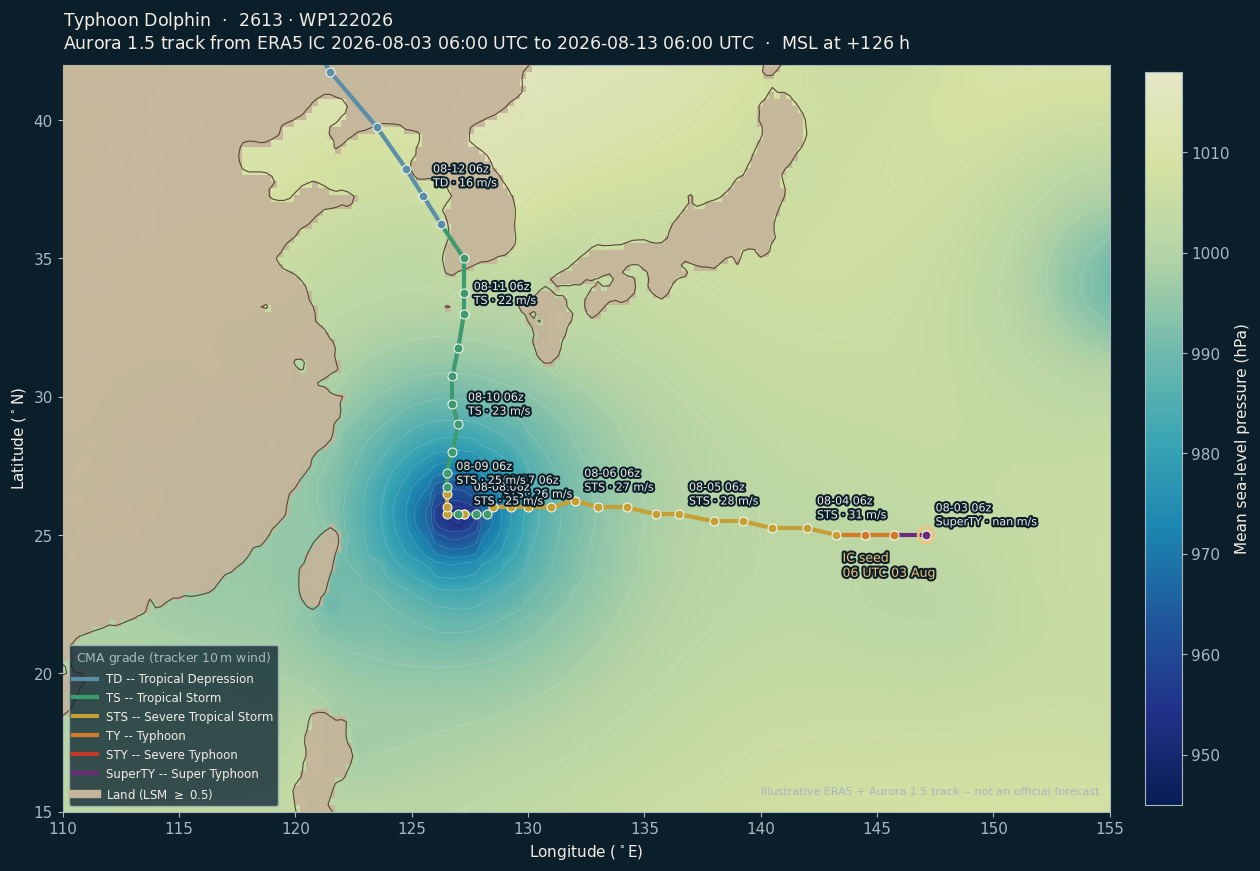

In [20]:
from __future__ import annotations

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

SEA = "#0B1F2A"
LAND = "#C4B49A"
TEXT = "#F2EDE6"
MUTED = "#A8B7C0"
MSL_CMAP = "YlGnBu_r"

# Wide enough for westward approach into the East China Sea by 10 Aug
LON_MIN, LON_MAX = 110.0, 155.0
LAT_MIN, LAT_MAX = 15.0, 42.0

lsm = batch.static_vars["lsm"].detach().cpu().numpy()
lat_full = batch.metadata.lat.detach().cpu().numpy()
lon_full = batch.metadata.lon.detach().cpu().numpy()

bg_idx = min(len(preds) - 1, max(0, len(preds) // 2))
bg = preds[bg_idx]
msl_full = bg.surf_vars["msl"][0, 0].detach().cpu().numpy() / 100.0

lat_mask = (lat_full >= LAT_MIN) & (lat_full <= LAT_MAX)
lon_mask = (lon_full >= LON_MIN) & (lon_full <= LON_MAX)
lat_crop = lat_full[lat_mask]
lon_crop = lon_full[lon_mask]
msl_crop = msl_full[np.ix_(lat_mask, lon_mask)]
lsm_crop = lsm[np.ix_(lat_mask, lon_mask)].copy()
lat_ascending = bool(lat_crop[0] < lat_crop[-1])
if lat_ascending:
    msl_crop = msl_crop[::-1]
    lsm_crop = lsm_crop[::-1]
    lat_crop = lat_crop[::-1]

plt.rcParams.update({
    "figure.facecolor": SEA,
    "axes.facecolor": SEA,
    "savefig.facecolor": SEA,
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "axes.edgecolor": MUTED,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 11,
    "mathtext.default": "regular",
})

fig, ax = plt.subplots(figsize=(12.5, 8.6), constrained_layout=True)
extent = (float(lon_crop.min()), float(lon_crop.max()), float(lat_crop.min()), float(lat_crop.max()))

mesh = ax.imshow(
    msl_crop,
    extent=extent,
    origin="upper",
    aspect="auto",
    cmap=MSL_CMAP,
    vmin=945,
    vmax=1018,
    interpolation="bilinear",
    alpha=0.90,
    zorder=1,
)

lon_grid, lat_grid = np.meshgrid(lon_crop, lat_crop)
ax.contour(
    lon_grid,
    lat_grid,
    msl_crop,
    levels=np.arange(950, 1016, 4),
    colors="white",
    linewidths=0.3,
    alpha=0.30,
    zorder=2,
)

land_cmap = ListedColormap(["none", LAND])
ax.imshow(
    (lsm_crop >= 0.5).astype(float),
    extent=extent,
    origin="upper",
    aspect="auto",
    cmap=land_cmap,
    vmin=0,
    vmax=1,
    interpolation="nearest",
    zorder=3,
    alpha=0.92,
)
ax.contour(
    lon_grid,
    lat_grid,
    lsm_crop,
    levels=[0.5],
    colors="#5A4632",
    linewidths=0.8,
    zorder=4,
)

points = np.column_stack([track["lon"].to_numpy(), track["lat"].to_numpy()])
if len(points) >= 2:
    segments = np.stack([points[:-1], points[1:]], axis=1)
    seg_colors = track["grade_color"].to_numpy()[:-1]
    ax.add_collection(
        LineCollection(segments, colors=seg_colors, linewidths=3.0, capstyle="round", zorder=5)
    )

halo = [pe.withStroke(linewidth=3.0, foreground=SEA)]
label_idx = {0, len(track) - 1}
label_idx.update(i for i, lead in enumerate(track["lead_h"]) if int(lead) % 24 == 0)

for pos, row in enumerate(track.itertuples()):
    ax.scatter(
        row.lon,
        row.lat,
        s=42,
        c=row.grade_color,
        edgecolors="white",
        linewidths=0.7,
        zorder=6,
    )
    if pos not in label_idx:
        continue
    label = (
        rf"{row.time.strftime('%m-%d %Hz')}"
        "\n"
        rf"{row.grade} ${{\cdot}}$ {row.wind:.0f} m/s"
    )
    ax.annotate(
        label,
        (row.lon, row.lat),
        textcoords="offset points",
        xytext=(7, 7),
        fontsize=8,
        color=TEXT,
        path_effects=halo,
        zorder=7,
    )

ax.scatter(
    [INIT_LON],
    [INIT_LAT],
    s=120,
    facecolors="none",
    edgecolors="#F0C27A",
    linewidths=2.0,
    zorder=8,
)
ax.annotate(
    "IC seed\n06 UTC 03 Aug",
    (INIT_LON, INIT_LAT),
    textcoords="offset points",
    xytext=(-60, -30),
    fontsize=9,
    color="#F0C27A",
    path_effects=halo,
)

ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel(r"Longitude ($^\circ$E)")
ax.set_ylabel(r"Latitude ($^\circ$N)")
ax.set_title(
    rf"{STORM_NAME_EN}  ${{\cdot}}$  {STORM_ID_WMO} ${{\cdot}}$ {STORM_ID_JTWC}"
    "\n"
    rf"Aurora 1.5 track from ERA5 IC {VALID_TIME.strftime('%Y-%m-%d %H:%M')} UTC "
    rf"to {track['time'].iloc[-1].strftime('%Y-%m-%d %H:%M')} UTC"
    rf"  ${{\cdot}}$  MSL at +{(bg_idx + 1) * 6} h",
    loc="left",
    fontsize=12.5,
    pad=12,
)

cbar = fig.colorbar(mesh, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Mean sea-level pressure (hPa)")
cbar.ax.yaxis.set_tick_params(color=MUTED)
plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color=MUTED)

legend_handles = [
    Line2D([0], [0], color=color, lw=3, label=f"{code} -- {label}")
    for _, code, label, color in CMA_GRADES
]
legend_handles.append(Line2D([0], [0], color=LAND, lw=6, label=r"Land (LSM $\geq$ 0.5)"))
leg = ax.legend(
    handles=legend_handles,
    title=r"CMA grade (tracker $10\,\mathrm{m}$ wind)",
    loc="lower left",
    frameon=True,
    facecolor="#122A36",
    edgecolor=MUTED,
    labelcolor=TEXT,
    title_fontsize=9,
    fontsize=8.5,
)
leg.get_title().set_color(MUTED)

ax.text(
    0.99,
    0.02,
    "Illustrative ERA5 + Aurora 1.5 track -- not an official forecast",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
    color=MUTED,
)
plt.show()

## 5. Daily MSL and track panels

One panel every $+24\,\mathrm{h}$ from the first day after the IC through the medium-range horizon. Land and the full track are drawn on each panel.

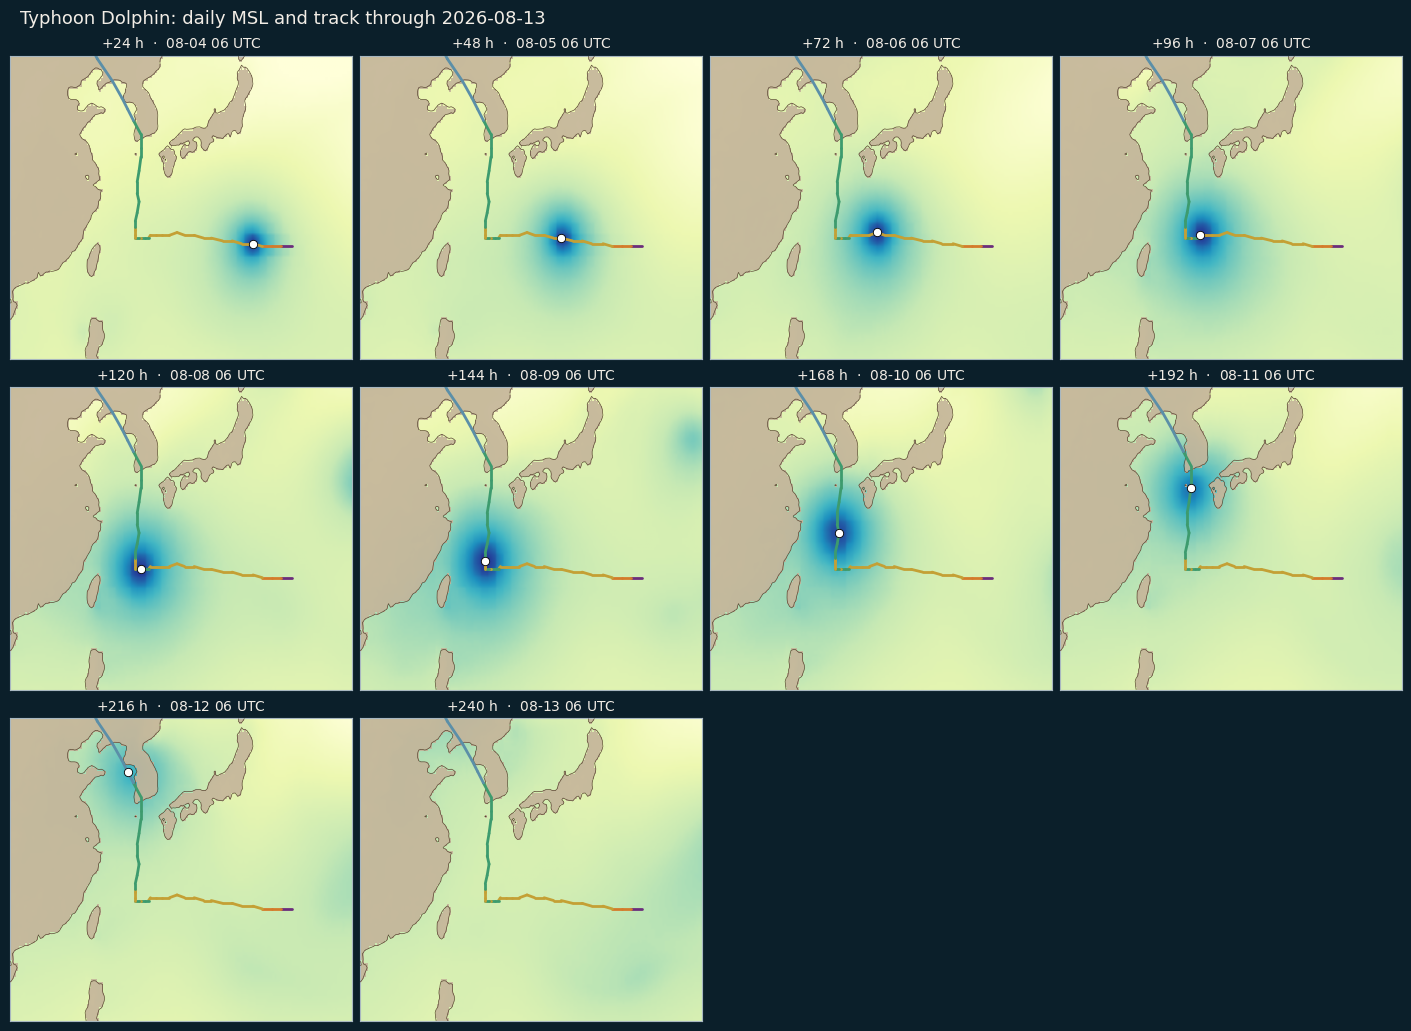

In [21]:
# Daily MSL panels: +24h ... through forecast end (prediction i is VALID_TIME + (i+1)*6 h)
daily_leads = list(range(24, ROLLOUT_STEPS * 6 + 1, 24))
panel_specs = []
for lead in daily_leads:
    idx = lead // 6 - 1
    if 0 <= idx < len(preds):
        panel_specs.append((lead, idx))

ncols = 4
nrows = int(np.ceil(len(panel_specs) / ncols))
fig, axs = plt.subplots(
    nrows, ncols, figsize=(14, 3.4 * nrows), squeeze=False, constrained_layout=True
)

for ax in axs.ravel():
    ax.set_facecolor(SEA)
    ax.axis("off")

for panel_i, (lead, idx) in enumerate(panel_specs):
    ax = axs[panel_i // ncols, panel_i % ncols]
    ax.axis("on")
    pred = preds[idx]
    msl = pred.surf_vars["msl"][0, 0].detach().cpu().numpy() / 100.0
    msl_c = msl[np.ix_(lat_mask, lon_mask)]
    lsm_c = lsm[np.ix_(lat_mask, lon_mask)].copy()
    if lat_ascending:
        msl_c = msl_c[::-1]
        lsm_c = lsm_c[::-1]

    ax.imshow(
        msl_c,
        extent=extent,
        origin="upper",
        aspect="auto",
        cmap=MSL_CMAP,
        vmin=945,
        vmax=1018,
        interpolation="bilinear",
        zorder=1,
    )
    ax.imshow(
        (lsm_c >= 0.5).astype(float),
        extent=extent,
        origin="upper",
        aspect="auto",
        cmap=land_cmap,
        vmin=0,
        vmax=1,
        interpolation="nearest",
        alpha=0.90,
        zorder=2,
    )
    ax.contour(
        lon_grid,
        lat_grid,
        lsm_c,
        levels=[0.5],
        colors="#5A4632",
        linewidths=0.5,
        zorder=3,
    )

    if len(points) >= 2:
        ax.add_collection(
            LineCollection(
                np.stack([points[:-1], points[1:]], axis=1),
                colors=track["grade_color"].to_numpy()[:-1],
                linewidths=2.0,
                capstyle="round",
                zorder=4,
            )
        )
    this = track[track["lead_h"] == lead]
    if len(this):
        ax.scatter(
            this.lon,
            this.lat,
            c="white",
            s=36,
            zorder=5,
            edgecolors="black",
            linewidths=0.6,
        )

    valid = pred.metadata.time[0]
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(
        rf"+{lead} h  ${{\cdot}}$  {valid.strftime('%m-%d %H')} UTC",
        fontsize=10,
        color=TEXT,
    )
    for spine in ax.spines.values():
        spine.set_color(MUTED)

fig.suptitle(
    rf"{STORM_NAME_EN}: daily MSL and track through {FORECAST_END.strftime('%Y-%m-%d')}",
    fontsize=13,
    x=0.01,
    ha="left",
    color=TEXT,
)
plt.show()

## 6. JTWC best-track verification (`bwp122026.dat`)

Download the ATCF b-deck (working best track) from NCAR TCGP, match Aurora tracker fixes to JTWC `BEST` times, plot both tracks, and report great-circle position error (km). Intensity from the tracker is **not** compared to JTWC wind (different quantities).

using cached b-deck: /content/assets/bwp122026.dat
JTWC BEST fixes: 52 from 2026-07-27 00:00:00 to 2026-08-08 18:00:00
matched times: 23  (2026-08-03 06:00:00 --> 2026-08-08 18:00:00)
position error (km): mean=96.6, median=72.1, rmse=128.9, max=296.5


,time,lead_h,lat_aurora,lon_aurora,lat_jtwc,lon_jtwc,error_km,wind_kt,mslp_hpa,grade
0,2026-08-03 06:00:00,0,25.00,147.10,25.0,147.1,0.0,95.0,949.0,SuperTY
1,2026-08-03 12:00:00,6,25.00,145.75,25.0,145.7,5.0,90.0,955.0,TY
2,2026-08-03 18:00:00,12,25.00,144.50,25.1,144.2,32.2,95.0,952.0,TY
3,2026-08-04 00:00:00,18,25.00,143.25,25.1,143.2,12.2,100.0,947.0,STS
4,2026-08-04 06:00:00,24,25.25,142.00,25.3,141.9,11.5,115.0,933.0,STS
5,2026-08-04 12:00:00,30,25.25,140.50,25.2,140.6,11.5,110.0,935.0,STS
6,2026-08-04 18:00:00,36,25.50,139.25,25.3,139.3,22.8,105.0,935.0,STS
7,2026-08-05 00:00:00,42,25.50,138.00,25.4,138.3,32.1,100.0,943.0,STS
8,2026-08-05 06:00:00,48,25.75,136.50,25.6,137.2,72.1,100.0,941.0,STS
9,2026-08-05 12:00:00,54,25.75,135.50,25.9,136.2,72.0,90.0,949.0,STS


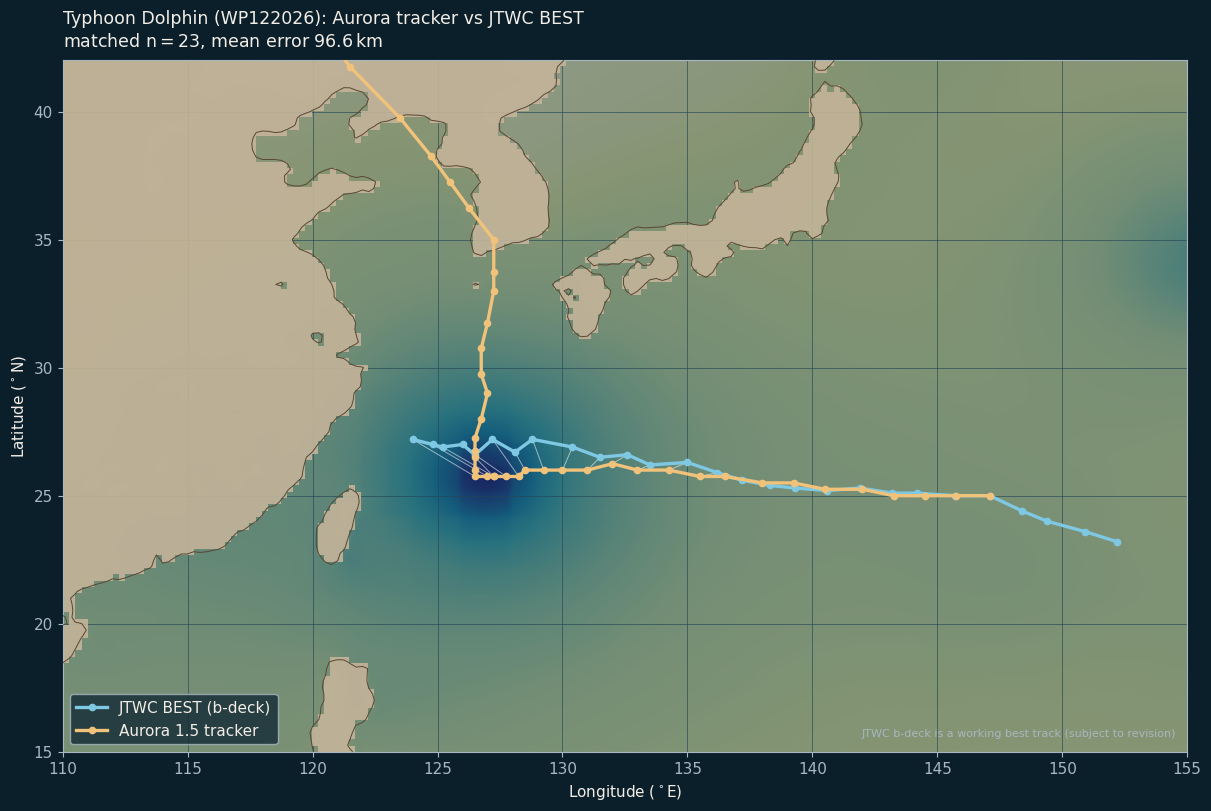

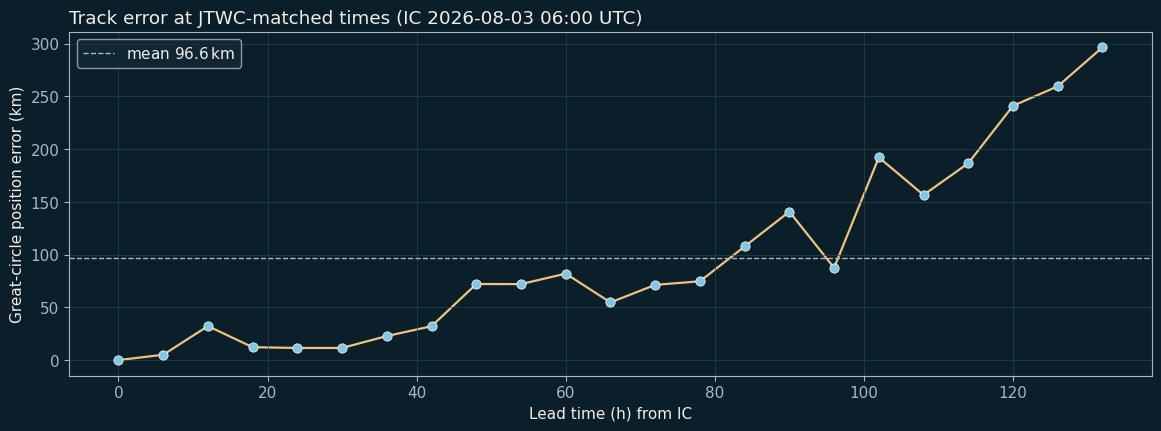

Per-time errors (km):
               time  lead_h  error_km
2026-08-03 06:00:00       0       0.0
2026-08-03 12:00:00       6       5.0
2026-08-03 18:00:00      12      32.2
2026-08-04 00:00:00      18      12.2
2026-08-04 06:00:00      24      11.5
2026-08-04 12:00:00      30      11.5
2026-08-04 18:00:00      36      22.8
2026-08-05 00:00:00      42      32.1
2026-08-05 06:00:00      48      72.1
2026-08-05 12:00:00      54      72.0
2026-08-05 18:00:00      60      82.0
2026-08-06 00:00:00      66      54.7
2026-08-06 06:00:00      72      71.3
2026-08-06 12:00:00      78      74.7
2026-08-06 18:00:00      84     107.7
2026-08-07 00:00:00      90     140.7
2026-08-07 06:00:00      96      87.4
2026-08-07 12:00:00     102     192.1
2026-08-07 18:00:00     108     156.5
2026-08-08 00:00:00     114     186.6
2026-08-08 06:00:00     120     241.0
2026-08-08 12:00:00     126     259.5
2026-08-08 18:00:00     132     296.5


In [22]:
from __future__ import annotations

import math
from datetime import datetime, timezone
from io import StringIO
from pathlib import Path
from urllib.request import Request, urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

BDECK_URLS = (
    "https://hurricanes.ral.ucar.edu/realtime/plots/northwestpacific/2026/wp122026/bwp122026.dat",
    "https://hurricanes.ral.ucar.edu/repository/data/bdecks_open/2026/bwp122026.dat",
)
BDECK_PATH = ASSET_ROOT / "bwp122026.dat"


def _download_bdeck(path: Path) -> Path:
    if path.is_file() and path.stat().st_size > 0:
        print("using cached b-deck:", path)
        return path
    last_err: Exception | None = None
    for url in BDECK_URLS:
        try:
            req = Request(url, headers={"User-Agent": "flash-aurora-dolphin-notebook"})
            with urlopen(req, timeout=60) as resp:
                text = resp.read().decode("utf-8", errors="replace")
            if "BEST" not in text:
                raise RuntimeError(f"unexpected b-deck content from {url}")
            path.write_text(text)
            print("downloaded b-deck:", url)
            print("saved:", path)
            return path
        except Exception as exc:  # noqa: BLE001 - try fallback mirrors
            last_err = exc
            print("failed:", url, "->", exc)
    raise RuntimeError(f"could not download bwp122026.dat: {last_err}")


def _parse_atcf_lat(token: str) -> float:
    token = token.strip()
    hem = token[-1].upper()
    value = int(token[:-1]) / 10.0
    if hem == "S":
        return -value
    if hem != "N":
        raise ValueError(f"bad ATCF lat: {token}")
    return value


def _parse_atcf_lon(token: str) -> float:
    token = token.strip()
    hem = token[-1].upper()
    value = int(token[:-1]) / 10.0
    if hem == "W":
        value = -value
    elif hem != "E":
        raise ValueError(f"bad ATCF lon: {token}")
    return value % 360.0


def load_jtwc_bdeck(path: Path) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for line in path.read_text().splitlines():
        if not line.strip():
            continue
        parts = [p.strip() for p in line.split(",")]
        if len(parts) < 10:
            continue
        if parts[4] != "BEST":
            continue
        # Analysis fixes only (tau = 0)
        try:
            tau = int(parts[5])
        except ValueError:
            continue
        if tau != 0:
            continue
        yyyymmddhh = parts[2]
        time = datetime.strptime(yyyymmddhh, "%Y%m%d%H")
        wind_kt = float(parts[8]) if parts[8] else math.nan
        mslp_hpa = float(parts[9]) if parts[9] not in {"", "-999"} else math.nan
        rows.append(
            {
                "time": time,
                "lat": _parse_atcf_lat(parts[6]),
                "lon": _parse_atcf_lon(parts[7]),
                "wind_kt": wind_kt,
                "mslp_hpa": mslp_hpa,
            }
        )
    if not rows:
        raise RuntimeError("no BEST tau=0 fixes parsed from b-deck")
    df = pd.DataFrame(rows).drop_duplicates(subset=["time"]).sort_values("time")
    return df.reset_index(drop=True)


def haversine_km(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    r_earth_km = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(((lon2 - lon1 + 180.0) % 360.0) - 180.0)
    a = math.sin(dphi / 2.0) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2.0) ** 2
    return 2.0 * r_earth_km * math.asin(min(1.0, math.sqrt(a)))


bdeck_path = _download_bdeck(BDECK_PATH)
jtwc = load_jtwc_bdeck(bdeck_path)
print("JTWC BEST fixes:", len(jtwc), "from", jtwc["time"].iloc[0], "to", jtwc["time"].iloc[-1])

aurora_cmp = track[["time", "lat", "lon", "lead_h", "grade"]].copy()
# Normalise timezone-naive timestamps for merging
aurora_cmp["time"] = pd.to_datetime(aurora_cmp["time"]).dt.tz_localize(None)
jtwc["time"] = pd.to_datetime(jtwc["time"])

merged = aurora_cmp.merge(jtwc, on="time", how="inner", suffixes=("_aurora", "_jtwc"))
if merged.empty:
    raise RuntimeError(
        "no overlapping times between Aurora track and JTWC BEST. "
        "Check VALID_TIME / rollout coverage vs b-deck availability."
    )

merged["error_km"] = [
    haversine_km(la, lo, lj, oj)
    for la, lo, lj, oj in zip(
        merged["lat_aurora"],
        merged["lon_aurora"],
        merged["lat_jtwc"],
        merged["lon_jtwc"],
    )
]

print(
    f"matched times: {len(merged)}  "
    f"({merged['time'].iloc[0]} --> {merged['time'].iloc[-1]})"
)
print(
    "position error (km): "
    f"mean={merged['error_km'].mean():.1f}, "
    f"median={merged['error_km'].median():.1f}, "
    f"rmse={math.sqrt((merged['error_km'] ** 2).mean()):.1f}, "
    f"max={merged['error_km'].max():.1f}"
)
display(
    merged[
        [
            "time",
            "lead_h",
            "lat_aurora",
            "lon_aurora",
            "lat_jtwc",
            "lon_jtwc",
            "error_km",
            "wind_kt",
            "mslp_hpa",
            "grade",
        ]
    ].round({"lat_aurora": 2, "lon_aurora": 2, "lat_jtwc": 2, "lon_jtwc": 2, "error_km": 1})
)

# --- Track map: Aurora vs JTWC ---
SEA = "#0B1F2A"
LAND = "#C4B49A"
TEXT = "#F2EDE6"
MUTED = "#A8B7C0"
AURORA_COLOR = "#F0C27A"
JTWC_COLOR = "#7EC8E3"

plt.rcParams.update({
    "figure.facecolor": SEA,
    "axes.facecolor": SEA,
    "savefig.facecolor": SEA,
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "axes.edgecolor": MUTED,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 11,
    "mathtext.default": "regular",
})

fig, ax = plt.subplots(figsize=(12.0, 8.0), constrained_layout=True)

# Reuse land/MSL crop from earlier cells when available
if "msl_crop" in globals() and "extent" in globals():
    ax.imshow(
        msl_crop,
        extent=extent,
        origin="upper",
        aspect="auto",
        cmap="YlGnBu_r",
        vmin=945,
        vmax=1018,
        interpolation="bilinear",
        alpha=0.55,
        zorder=1,
    )
if "lsm_crop" in globals() and "land_cmap" in globals() and "extent" in globals():
    ax.imshow(
        (lsm_crop >= 0.5).astype(float),
        extent=extent,
        origin="upper",
        aspect="auto",
        cmap=land_cmap,
        vmin=0,
        vmax=1,
        interpolation="nearest",
        alpha=0.90,
        zorder=2,
    )
    if "lon_grid" in globals() and "lat_grid" in globals():
        ax.contour(
            lon_grid,
            lat_grid,
            lsm_crop,
            levels=[0.5],
            colors="#5A4632",
            linewidths=0.7,
            zorder=3,
        )

# JTWC segment overlapping the Aurora forecast window (+ a little history)
t0 = pd.Timestamp(VALID_TIME)
t1 = pd.Timestamp(track["time"].iloc[-1])
jtwc_window = jtwc[(jtwc["time"] >= t0 - pd.Timedelta(hours=24)) & (jtwc["time"] <= t1)].copy()

ax.plot(
    jtwc_window["lon"],
    jtwc_window["lat"],
    color=JTWC_COLOR,
    lw=2.4,
    marker="o",
    markersize=4.5,
    zorder=5,
    label="JTWC BEST (b-deck)",
)
ax.plot(
    track["lon"],
    track["lat"],
    color=AURORA_COLOR,
    lw=2.4,
    marker="o",
    markersize=4.5,
    zorder=6,
    label="Aurora 1.5 tracker",
)

# Pair lines at matched times
for _, row in merged.iterrows():
    ax.plot(
        [row["lon_jtwc"], row["lon_aurora"]],
        [row["lat_jtwc"], row["lat_aurora"]],
        color="white",
        lw=0.7,
        alpha=0.55,
        zorder=4,
    )

ax.set_xlim(LON_MIN if "LON_MIN" in globals() else 110.0, LON_MAX if "LON_MAX" in globals() else 155.0)
ax.set_ylim(LAT_MIN if "LAT_MIN" in globals() else 15.0, LAT_MAX if "LAT_MAX" in globals() else 42.0)
ax.set_xlabel(r"Longitude ($^\circ$E)")
ax.set_ylabel(r"Latitude ($^\circ$N)")
ax.set_title(
    rf"{STORM_NAME_EN} ({STORM_ID_JTWC}): Aurora tracker vs JTWC BEST"
    "\n"
    rf"matched $n={len(merged)}$, mean error ${merged['error_km'].mean():.1f}\,\mathrm{{km}}$",
    loc="left",
    fontsize=12.5,
    pad=10,
)
ax.legend(loc="lower left", facecolor="#122A36", edgecolor=MUTED, labelcolor=TEXT)
ax.text(
    0.99,
    0.02,
    "JTWC b-deck is a working best track (subject to revision)",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
    color=MUTED,
)
ax.grid(True, color="#244556", lw=0.6, alpha=0.75)
plt.show()

# --- Error vs lead time ---
fig, ax = plt.subplots(figsize=(11.5, 4.2), constrained_layout=True)
ax.set_facecolor(SEA)
ax.plot(merged["lead_h"], merged["error_km"], color=AURORA_COLOR, lw=1.6, zorder=1)
ax.scatter(merged["lead_h"], merged["error_km"], c=JTWC_COLOR, s=45, zorder=2, edgecolors="white", linewidths=0.5)
ax.axhline(merged["error_km"].mean(), color=MUTED, ls="--", lw=1.0, label=rf"mean ${merged['error_km'].mean():.1f}\,\mathrm{{km}}$")
ax.set_xlabel(r"Lead time (h) from IC")
ax.set_ylabel(r"Great-circle position error (km)")
ax.set_title(
    rf"Track error at JTWC-matched times "
    rf"(IC {VALID_TIME.strftime('%Y-%m-%d %H:%M')} UTC)",
    loc="left",
)
ax.grid(True, color="#244556", lw=0.6, alpha=0.8)
ax.legend(loc="upper left", facecolor="#122A36", edgecolor=MUTED, labelcolor=TEXT)
for spine in ax.spines.values():
    spine.set_color(MUTED)
plt.show()

print("Per-time errors (km):")
print(
    merged[["time", "lead_h", "error_km"]]
    .assign(error_km=lambda d: d["error_km"].round(1))
    .to_string(index=False)
)

## 7. Shutdown

In [23]:
engine.close()
print("done")

done
